#Arquivo criado para hospedar os códigos e respostas das perguntas 1 a 10 do arquivo "perguntas_sql.md" em Python.

**#Primeiro passo**: importação das bases de dados do GCP.

In [5]:
import basedosdados as bd
import pandas as pd

PROJECT_ID = "desafio-empm-ulisses-gomes" 

print("Baixando dados do GCP")

# Baixando as tabelas 'dados_mestres_bairro' e 'turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos'.
df_bairros = bd.read_sql("SELECT * FROM `datario.dados_mestres.bairro`", billing_project_id=PROJECT_ID)
df_eventos = bd.read_sql("SELECT * FROM `datario.turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos`", billing_project_id=PROJECT_ID)

#Baixando a tabela 'adm_central_atendimento_1746.chamado' com o filtros para não exceder a cota de consultas.
#Para as perguntas de 1 a 5, baixamos apenas os chamados do dia 01/04/2023
query_p1 = "SELECT * FROM `datario.adm_central_atendimento_1746.chamado` WHERE DATE(data_inicio) = '2023-04-01'"
df_chamados_p1 = bd.read_sql(query_p1, billing_project_id=PROJECT_ID)
#Para as perguntas 6 a 10, baixamos apenas os chamados de Perturbação do Sossego entre 2022 e 2024.
query_p2 = """
SELECT * FROM `datario.adm_central_atendimento_1746.chamado` 
WHERE id_subtipo = '5071' AND DATE(data_inicio) BETWEEN '2022-01-01' AND '2024-12-31'
"""
df_chamados_p2 = bd.read_sql(query_p2, billing_project_id=PROJECT_ID)

#Transformando as colunas de datas para o formato 'datetime.date' do pandas.
df_chamados_p2['data_inicio'] = pd.to_datetime(df_chamados_p2['data_inicio']).dt.date
df_eventos['data_inicial'] = pd.to_datetime(df_eventos['data_inicial']).dt.date
df_eventos['data_final'] = pd.to_datetime(df_eventos['data_final']).dt.date

print("Bases carregadas")

2026-03-16 19:37:27.387 | WARNING  | basedosdados._warnings:show_warnings:94 - You are using an outdated version of basedosdados (2.0.2). Please upgrade to the latest version (2.0.3) using 'pip install --upgrade basedosdados'.


Baixando dados do GCP
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Bases carregadas


**#PERGUNTA 1**- Quantos chamados foram registrados no dia 01/04/2023?

In [6]:
#Objetivo do código, aplicar 'len' para contar o número de chamados registrados no dia 01/04/2023.
q1_resposta = len(df_chamados_p1)
print(f"Resposta: foram registrados {q1_resposta} chamados em 01/04/2023:")

Resposta: foram registrados 2067 chamados em 01/04/2023:


**#PERGUNTA 2**- Qual foi o bairro com o maior número de chamados registrados no dia 01/04/2023?

In [7]:
# Objetivo da código: aplicar 'valuecounts e 'idxmax' para contar os chamados e retornar apenas o chamado mais registrado
q2_resposta = df_chamados_p1['tipo'].value_counts().idxmax()
print(f"Resposta: o chamado mais registrado foi o de '{q2_resposta}'")

Resposta: o chamado mais registrado foi o de 'Estacionamento irregular'


#Mesclagem 'merge' das tabelas 'dados_mestres_bairro' e 'adm_central_atendimento_1746.chamado'

In [8]:
df_merged_p1 = df_chamados_p1.merge(df_bairros, on='id_bairro', how='left')
print("Mesclagem executada")

Mesclagem executada


**#PERGUNTA 3**- Quais os nomes dos 3 bairros que mais tiveram chamados abertos nesse dia?

In [9]:
#objetivo do código: aplicar 'valuecounts' para contar os chamados por bairro e 'head(3)' para retornar apenas os 3 maiores.
q3_resposta = df_merged_p1['nome'].value_counts().head(3) #Retorna apenas os 3 bairros geo-referenciados nas reclamações com mais chamados registrados.
print("\n" + "_" * 55)
print("RESULTADO: TOP 3 BAIRROS")
print("_" * 55)
for posicao, (bairro, quantidade) in enumerate(q3_resposta.items(), start=1): #Itera por meio do 'enumerate' sobre os bairros e suas respectivas quantidades, formatando a saída para exibir a posição, nome do bairro e quantidade de chamados.
    print(f" {posicao}º Lugar | {bairro.ljust(25)} | {quantidade} chamados")

print("_" * 55 + "\n")


_______________________________________________________
RESULTADO: TOP 3 BAIRROS
_______________________________________________________
 1º Lugar | Campo Grande              | 125 chamados
 2º Lugar | Tijuca                    | 100 chamados
 3º Lugar | Barra da Tijuca           | 62 chamados
_______________________________________________________



**Observação** Como descobrimos na nossa exploração inicial em SQL (Pergunta 3 e 5), existem chamados no sistema 1746 que não possuem um 'id_bairro' associado. Geralmente, são serviços atrelados a entidades móveis (como reclamações de linhas de Ônibus ou BRT) ou serviços digitais, que não possuem geolocalização fixa. 

Como a função 'value_counts()' tem como parâmetro o 'dropna=True', que desconsidera os valores nulos, optou-se aqui pelo uso dessa função e assim não evidenciar as reclamações não geolocalizadas, como foi evidenciado na consulta SQL.

**PERGUNTA 4**- Qual o nome da subprefeitura com mais chamados abertos nesse dia?

In [10]:
#Objetivo do código: aplicar 'valuecounts' para contar os chamados por subprefeitura e 'idxmax' para retornar apenas a subprefeitura com mais chamados registrados.
q4_resposta = df_merged_p1['subprefeitura'].value_counts().idxmax()
print(f"\nResposta: A subprefeitura com mais chamados foi a '{q4_resposta}'")


Resposta: A subprefeitura com mais chamados foi a 'Subprefeitura da Zona Norte'


**PERGUNTA 5:** - Existe algum chamado aberto nesse dia que não foi associado a um bairro ou subprefeitura na tabela de bairros? Se sim, por que isso acontece?

In [11]:
#Objetivo do código: aplicar 'isnull' para identificar os chamados sem bairro associado e 'len' para contar quantos são.
chamados_sem_bairro = df_merged_p1[df_merged_p1['id_bairro'].isnull()]
print(f"\nResultado: Sim, existem {len(chamados_sem_bairro)} chamados sem bairro associado.")
print("Motivação:Ao analisar a consulta, observa-se que esses chamados se referem a trasnportes como 'Veículos' e /ou 'BRT (corredor expresso de ônibus)' - de maneira similar a pergunta 3 - 'Fiscalização Eletrônica' e 'Ouvidoria - CLF'")


Resultado: Sim, existem 260 chamados sem bairro associado.
Motivação:Ao analisar a consulta, observa-se que esses chamados se referem a trasnportes como 'Veículos' e /ou 'BRT (corredor expresso de ônibus)' - de maneira similar a pergunta 3 - 'Fiscalização Eletrônica' e 'Ouvidoria - CLF'


**PERGUNTA 6**- Quantos chamados de Perturbação do sossego foram abertos nesse período (01/01/2022 a 31/12/2024)?

In [12]:
#Objetivo do código: aplicar 'len' para contar o número de chamados de perturbação do sossego registrados entre 2022 e 2024.
q6_resposta = len(df_chamados_p2)
print(f"Resultado:Total de chamados de perturbação do sossego (2022-2024): {q6_resposta} chamados")

Resultado:Total de chamados de perturbação do sossego (2022-2024): 57532 chamados


**Etapa intermediária:** Corrigindo padrão de datas da tabela 'datario.turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos'

In [13]:
#Objetivo do código: fazer o tratamento dos dados para corrigir os eventos com datas despadronizadas(Rock in Rio e Réveillon) e unir com os eventos que já possuem as datas corretas preenchidas, para posteriormente cruzar com os chamados e analisar o impacto dos eventos nos chamados de perturbação do sossego.
import pandas as pd

df_eventos_limpo = df_eventos.dropna(subset=['data_inicial', 'data_final']).copy() #Filtra apenas os eventos que já possuem as datas corretas

#Corrige apenas as datas dos eventos que estão com informações despadronizadas(Rock in Rio e Réveillon)
eventos_corrigidos = pd.DataFrame({
    'evento': ['Rock in Rio', 'Rock in Rio', 'Reveillon'],
    'data_inicial': ['2024-09-13', '2024-09-19', '2024-12-29'],
    'data_final': ['2024-09-15', '2024-09-22', '2025-01-01']
})
eventos_corrigidos['data_inicial'] = pd.to_datetime(eventos_corrigidos['data_inicial']).dt.date #converte as colunas de datas para o formato 'datetime.date'

df_eventos_tratado = pd.concat([df_eventos_limpo, eventos_corrigidos], ignore_index=True)
print(df_eventos_tratado.to_string())

                            ano data_inicial  data_final       evento  taxa_ocupacao
0         18/02 a 21/02 de 2023   2023-02-18  2023-02-21     Carnaval         0.9554
1            10/02 a 14/02/2024   2024-02-10  2024-02-14     Carnaval            NaN
2         02/09 a 04/09 de 2022   2022-09-02  2022-09-04  Rock in Rio         0.8184
3         08/09 a 11/09 de 2022   2022-09-08  2022-09-11  Rock in Rio         0.9451
4  30-31/12 e 01/01 (2022-2023)   2022-12-30  2023-01-01    Réveillon         0.9251
5  30-31/12 e 01/01 (2023-2024)   2023-12-30  2024-01-01    Réveillon            NaN
6                           NaN   2024-09-13  2024-09-15  Rock in Rio            NaN
7                           NaN   2024-09-19  2024-09-22  Rock in Rio            NaN
8                           NaN   2024-12-29  2025-01-01    Reveillon            NaN


**PERGUNTA 7**-Selecione os chamados com esse subtipo que foram abertos durante os eventos contidos na tabela de eventos (Reveillon, Carnaval e Rock in Rio).

In [14]:
df_cross = df_chamados_p2.merge(df_eventos_tratado, how='cross')

# PADRONIZANDO TODAS AS COLUNAS PARA O MESMO FORMATO DE DATA (IGNORANDO AS HORAS) PARA EVITAR O TYPEERROR
df_cross['data_inicio'] = pd.to_datetime(df_cross['data_inicio']).dt.normalize()
df_cross['data_inicial'] = pd.to_datetime(df_cross['data_inicial']).dt.normalize()
df_cross['data_final'] = pd.to_datetime(df_cross['data_final']).dt.normalize()

df_chamados_eventos = df_cross[(df_cross['data_inicio'] >= df_cross['data_inicial']) & 
                               (df_cross['data_inicio'] <= df_cross['data_final'])]

print("\nResultado:Total de chamados de perturbação do sossego durante os eventos foi de", len(df_chamados_eventos))


Resultado:Total de chamados de perturbação do sossego durante os eventos foi de 1511


**PERGUNTA 8**-Quantos chamados desse subtipo foram abertos em cada evento?

In [15]:
#Etapa intermediária: importando a biblioteca 'matplotlib' para visualização de dados.
import matplotlib.pyplot as plt

In [16]:
#Objetivo do código: calcular o total de chamados de perturbação do sossego durante cada evento.
df_chamados_eventos['evento'] = df_chamados_eventos['evento'].str.replace('é', 'e').str.replace('É', 'E') #normalziando nomes

#Calcula o total de chamados de perturbação do sossego durante cada evento.
q8_resposta = df_chamados_eventos['evento'].value_counts()
q8_resposta.name = 'count'
print("\nResposta:Chamados por Evento:")
display(q8_resposta)


Resposta:Chamados por Evento:


evento
Rock in Rio    958
Reveillon      298
Carnaval       255
Name: count, dtype: int64

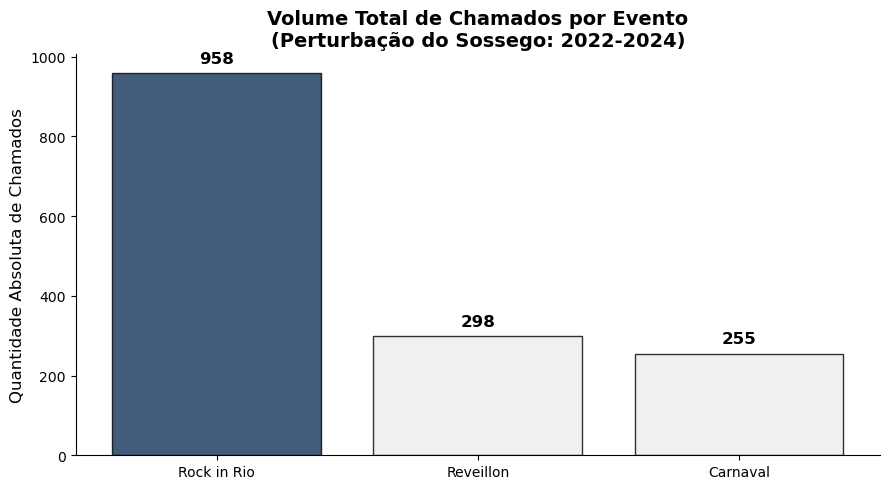

In [17]:
#Objetivo do código: extrair os eventos e as quantidades de chamados para listas separadas, e monstar um gráfico com 'matplotlib.pyplot'.
eventos = q8_resposta.index.tolist() #extrai os eventos e as quantidades de chamados para listas separadas, facilitando a construção do gráfico.
total_chamados = q8_resposta.values.tolist()
plt.figure(figsize=(9, 5))#configura o tamanho da figura
#adicionando cores personalizadas presentes no manual de marca da prefeitura do Rio de Janeiro.
cores_eventos = ['#13335a'] + ['#eceded'] * (len(eventos) - 1)
barras = plt.bar(eventos, total_chamados, color=cores_eventos, edgecolor='black', alpha=0.8)
plt.title('Volume Total de Chamados por Evento\n(Perturbação do Sossego: 2022-2024)', fontsize=14, fontweight='bold')#Adiciona títulos e rótulos aos eixos
plt.ylabel('Quantidade Absoluta de Chamados', fontsize=12)
#calcula uma posição para os rótulos de dados para evitar sobreposição de barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + (max(total_chamados) * 0.02),
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.gca().spines['top'].set_visible(False)#Remoção a borda superior da figura
plt.gca().spines['right'].set_visible(False)
#Exibição do resultado
plt.tight_layout()
plt.show()

**Observação:** Como pode ser observado no gráfico acima, O Rock in Rio é o evento que mais distoa dos demais com reclamações de perrturbação do sossego necessitando então de um maior incremento a fiscalização desse tipo de chamado nas datas desse evento

**PERGUNTA 9**-Qual evento teve a maior média diária de chamados abertos desse subtipo?

In [18]:
#objetivo do código: calcular a média diária de chamados para cada evento, considerando a duração de cada evento.
import pandas as pd

# --- Normalização igual ao SQL (Q10 faz, mas aqui não atrapalha) ---
df_eventos_tratado = df_eventos_tratado.copy()
df_chamados_p2 = df_chamados_p2.copy()

df_eventos_tratado["evento"] = (
    df_eventos_tratado["evento"].astype(str)
    .str.replace("é", "e", regex=False)
    .str.replace("É", "E", regex=False)
    .str.strip()
)

# Datas como DATE (equivalente ao DATE(c.data_inicio))
df_eventos_tratado["data_inicial"] = pd.to_datetime(df_eventos_tratado["data_inicial"], errors="coerce").dt.date
df_eventos_tratado["data_final"]   = pd.to_datetime(df_eventos_tratado["data_final"], errors="coerce").dt.date

# --- EventosTratados do SQL: remove nulos + UNION ALL extras ---
eventos_trat = df_eventos_tratado.dropna(subset=["data_inicial", "data_final"])[
    ["evento", "data_inicial", "data_final"]
].copy()

extras = pd.DataFrame({
    "evento": ["Rock in Rio", "Rock in Rio", "Reveillon"],
    "data_inicial": [
        pd.to_datetime("2024-09-13").date(),
        pd.to_datetime("2024-09-19").date(),
        pd.to_datetime("2024-12-29").date(),
    ],
    "data_final": [
        pd.to_datetime("2024-09-15").date(),
        pd.to_datetime("2024-09-22").date(),
        pd.to_datetime("2025-01-01").date(),
    ],
})

eventos_trat = pd.concat([eventos_trat, extras], ignore_index=True)

# --- Filtrar chamados igual ao SQL ---
df_chamados_p2["data_inicio"] = pd.to_datetime(df_chamados_p2["data_inicio"], errors="coerce").dt.date
ch = df_chamados_p2.dropna(subset=["data_inicio"]).copy()

ch = ch[
    (ch["id_subtipo"] == "5071") &
    (ch["data_inicio"] >= pd.to_datetime("2022-01-01").date()) &
    (ch["data_inicio"] <= pd.to_datetime("2024-12-31").date())
].copy()

# --- JOIN BETWEEN (igual ao SQL) via chave dummy (evita how='cross') ---
ch["_k"] = 1
eventos_trat["_k"] = 1

cross = ch.merge(eventos_trat, on="_k", how="inner").drop(columns="_k")

ch_eventos = cross[
    (cross["data_inicio"] >= cross["data_inicial"]) &
    (cross["data_inicio"] <= cross["data_final"])
].copy()

# --- Agregação igual ao SQL Q9 (COUNT + MAX/MAX + media) ---
res_q9 = ch_eventos.groupby("evento", as_index=False).agg(
    total_chamados=("id_chamado", "count"),
    max_data_inicial=("data_inicial", "max"),
    max_data_final=("data_final", "max"),
)

res_q9["dias_de_evento"] = (
    (pd.to_datetime(res_q9["max_data_final"]) - pd.to_datetime(res_q9["max_data_inicial"])).dt.days + 1
)

res_q9["media_diaria"] = res_q9["total_chamados"] / res_q9["dias_de_evento"]

# LIMIT 1
campeao_media = res_q9.sort_values("media_diaria", ascending=False).iloc[0]

print(
    f"\nResultado: O evento com maior média diária foi o {campeao_media['evento']} "
    f"com {campeao_media['media_diaria']:.2f} chamados/dia."
)


Resultado: O evento com maior média diária foi o Rock in Rio com 239.50 chamados/dia.


**PERGUNTA 10**-Compare as médias diárias de chamados abertos desse subtipo durante os eventos específicos (Reveillon, Carnaval e Rock in Rio) e a média diária de chamados abertos desse subtipo considerando todo o período de 01/01/2022 até 31/12/2024.

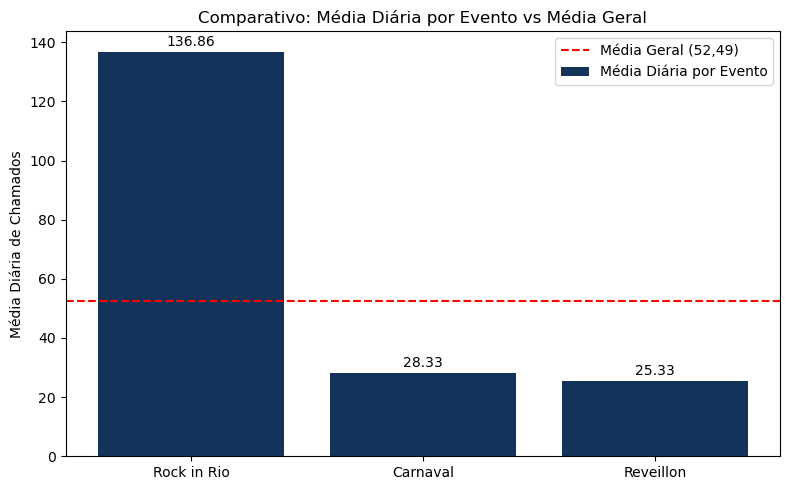

In [19]:
#objetivo do código: comparar a média diária de chamados para cada evento com a média geral de chamados por dia no período de 2022 a 2024, por meio de um gráfico comparativo.
import matplotlib.pyplot as plt #aqui foi escolhido a montagem dos valores diretos em um gráfico para facilitar a visualização comparativa entre os eventos e a média geral de chamados por dia já executada via SQL
data = {
    'evento': ['Rock in Rio', 'Carnaval', 'Reveillon'],
    'media_diaria_evento': [136.86, 28.33, 25.33],
    'media_diaria_geral': [52.49, 52.49, 52.49]
}
df = pd.DataFrame(data) #montando os valores em um DataFrame para facilitar a construção do gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df['evento'], df['media_diaria_evento'], color='#13335a', label='Média Diária por Evento')
ax.axhline(y=52.49, color='red', linestyle='--', label='Média Geral (52,49)')

for bar in bars: #adicionando rótulo de dados
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}', ha='center', va='bottom')

ax.set_ylabel('Média Diária de Chamados') #ajustando visualização
ax.set_title('Comparativo: Média Diária por Evento vs Média Geral')
ax.legend()
plt.tight_layout()

plt.show()

**Observação:** A análise do resultado da Pergunta 10, visualizada no gráfico acima, indica que a média diária geral de reclamações de perturbação ao sossego foi de 52,49 chamados por dia ao longo desses 3 anos. 
Considerando a média diária conjunta de todas as ocorrências dos eventos solicitados, verificamos que apenas um evento superou a média diária do período analisado. O Rock in Rio registrou uma média de 136,86 chamados por dia (mais de 2,5 vezes a média diária geral para esse subtipo de chamado no período observado). 
O Carnaval (com média de 28,33) e o Reveillon (25.33) registraram valor acima da média diária calculada ao longo dos 3 anos. Com isso, observamos o potencial que o Rock in Rio têm de impactar negativamente a vida dos cidadãos cariocas. 
Portanto, recomenda-se a ampla divulgação do serviço de fiscalização de perturbação do sossego, por meio da Central de Atendimento 1746, antes e durante o Rock in Rio.
Essa divulgação deve ser intensificada em mídias tradicionais, como rádio e TV aberta, e também em canais digitais e redes sociais, incluindo a página oficial da Prefeitura e a republicação por perfis institucionais de grande alcance, como o COR-Rio no Instagram, que possui elevado engajamento e frequente acompanhamento junto à população carioca. 
De forma complementar, recomenda-se a suplementação e maior integração estratégica entre as equipes de fiscalização e as responsáveis pelo tratamento e encaminhamento dos chamados durante esses eventos, com o objetivo de ampliar a eficiência operacional, reduzir o tempo de resposta e qualificar o atendimento à população. 
De forma parelela, essa análise pode ser incrementada a partir do cruzamento das informações de geolocalização dos chamados de perturbação do sossego durante as edições do Rock in Rio para verificar se esses chamados, durante os dias do evento, se concentram em regiões ou bairros próximos a "Cidade do Rock" na Barra da Tijuca.
Com a adição desse prisma analítico, poderíamos aumentar o nexo causal entre as edições do Rock in Rio e o aumento substancial de reclamações relacionadas a perturbação do sossego, incrementando assim a capacidade de planejamento e tomada de decisão da prefeitura para as edições futuras do Rock in Rio.

Maior média diária e total de chamados por Bairro (2022-2024)

In [21]:
import basedosdados as bd
import pandas as pd

# Coloque o ID do seu projeto do Google Cloud aqui entre as aspas
meu_projeto_gcp = "desafio-empm-ulisses-gomes" 

# 1. Carregar a tabela de Chamados
print("Carregando chamados...")
df_chamados = bd.read_sql(
    query="SELECT * FROM `datario.adm_central_atendimento_1746.chamado`",
    billing_project_id=meu_projeto_gcp
)

# 2. Carregar a tabela de Bairros
print("Carregando bairros...")
df_bairros = bd.read_sql(
    query="SELECT * FROM `datario.dados_mestres.bairro`",
    billing_project_id=meu_projeto_gcp
)

print("Bases carregadas com sucesso!")

Carregando chamados...
Downloading: 100%|██████████|
Carregando bairros...
Downloading: 100%|██████████|
Bases carregadas com sucesso!


In [22]:
import pandas as pd

# 1. Filtrar apenas chamados de perturbação do sossego (Ajuste o nome da coluna/valor se necessário)
df_sossego = df_chamados[df_chamados['id_subtipo'] == '5071'].copy() # ou categoria == 'Perturbação do sossego'

# 2. Agrupar por id_bairro e contar o total de chamados
chamados_por_bairro = df_sossego.groupby('id_bairro').size().reset_index(name='total_chamados')

# 3. Cruzar (Merge) com a tabela de bairros para pegar o nome do bairro
# Presumindo que df_bairros tem 'id_bairro' e 'nome'
df_analise_geral = pd.merge(chamados_por_bairro, df_bairros[['id_bairro', 'nome']], on='id_bairro', how='left')

# 4. Calcular a média diária (1096 dias no período de 2022 a 2024)
dias_totais = 1096
df_analise_geral['media_diaria'] = df_analise_geral['total_chamados'] / dias_totais

# 5. Ordenar para ver os bairros campeões de reclamação
df_analise_geral = df_analise_geral.sort_values(by='total_chamados', ascending=False).reset_index(drop=True)

# Exibir os Top 10
print("Top 10 Bairros - Perturbação do Sossego (2022-2024):")
display(df_analise_geral.head(10))

Top 10 Bairros - Perturbação do Sossego (2022-2024):


,id_bairro,total_chamados,nome,media_diaria
0,24,8106,Copacabana,7.395985
1,20,6852,Botafogo,6.251825
2,144,6350,Campo Grande,5.793796
3,33,5774,Tijuca,5.268248
4,128,5662,Barra da Tijuca,5.166058
5,132,4522,Recreio dos Bandeirantes,4.125912
6,5,4062,Centro,3.706204
7,64,3135,Todos os Santos,2.860401
8,36,3135,Vila Isabel,2.860401
9,122,3036,Taquara,2.770073


2. Maior média diária e total por Bairro (Durante o Rock in Rio)

In [ ]:
pip install geopandas shapely

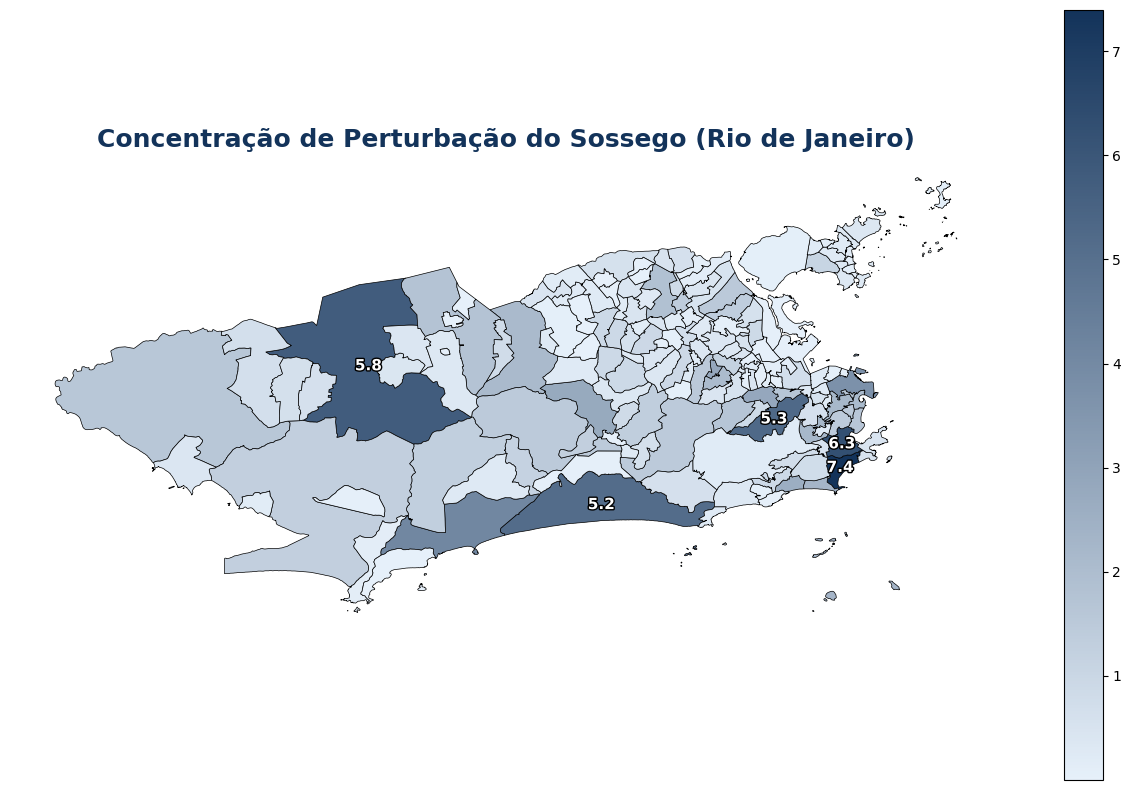

In [63]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects # 🪄 NOVO: Importando a ferramenta de efeitos visuais!
import geopandas as gpd

# 1. Criar o "degradê" personalizado com o seu azul exato
cor_escura = "#13335a"
cor_clara = "#e6f0fa" # Um azul bem clarinho para os bairros com pouca ocorrência
meu_cmap = mcolors.LinearSegmentedColormap.from_list("AzulCasaCivil", [cor_clara, cor_escura])

# 2. Devolver os "superpoderes" de mapa para a tabela
df_mapa = gpd.GeoDataFrame(df_mapa, geometry='geometry')

# 3. Configurar o tamanho da imagem (removi a linha duplicada)
fig, ax = plt.subplots(figsize=(16, 10))

# 4. Desenhar o mapa 
df_mapa.plot(column='media_diaria', 
             cmap=meu_cmap, 
             linewidth=0.5, 
             edgecolor='black', # Bordas pretas ou cinzas para destacar as divisões
             legend=True,
             ax=ax)

# 5. Selecionar os TOP bairros para receberem o rótulo de texto (ex: Top 5)
top_bairros = df_mapa.nlargest(5, 'media_diaria')

# 6. Iterar sobre esses top bairros para "carimbar" o valor no mapa
for idx, linha in top_bairros.iterrows():
    # Encontra o centro geográfico do bairro
    x = linha.geometry.centroid.x
    y = linha.geometry.centroid.y
    
    # Pega o valor da média e formata com 1 casa decimal (ex: 13.4)
    valor_texto = f"{linha['media_diaria']:.1f}"
    
    # Escreve o número no mapa usando o path_effects importado corretamente
    ax.text(x, y, valor_texto, 
            fontsize=11, 
            fontweight='bold', 
            color='white', # Letra branca para dar contraste com o azul escuro
            ha='center', va='center',
            path_effects=[path_effects.withStroke(linewidth=2, foreground="black")]) 

# 7. Remover as bordas e os eixos (latitude/longitude) para ficar limpo
ax.axis('off')

# 8. Título e exibição
plt.title("Concentração de Perturbação do Sossego (Rio de Janeiro)", fontsize=18, fontweight='bold', color=cor_escura)
plt.show()

CONCENTRAÇÃO DOS CHAMADOSS DE PERTURBAÇÃO DO SOSEGO A CADA 10 MIL HABITANTES

In [54]:
import pandas as pd

# Substitua o nome abaixo pelo nome exato do arquivo que acabou de baixar!
# Olha o "r" minúsculo bem aqui antes das aspas duplas! 👇
df_populacao = pd.read_csv(r"c:\Users\03609085193\Downloads\censo_2022.csv")

# Vamos ver as primeiras linhas para descobrir o nome da coluna de população
display(df_populacao.head())

,nome,codbairro,regiao_adm,codra,area_plane,Total_de_pessoas_2010,Total_de_pessoas_2022,diferenca_de_pessoas,Total_de_domicilios_2022,Total_DP_2022,Total_DC,Total_DP_Ocup_2010,Total_DP_Ocup_2022,diferenca_de_DP,Shape_Length,Shape_Area,OBJECTID_1
0,Grumari,133,BARRA DA TIJUCA,24,4,167,184,17,85,85,0,44,68,24,23375.374038,9.598851e+06,1
1,Jardim Sulacap,137,REALENGO,33,5,13062,14396,1334,6389,6387,2,4390,5481,1091,14519.328424,7.869225e+06,2
2,Saúde,1,PORTUARIA,1,1,2749,1876,-873,1001,988,13,946,801,-145,2646.220568,3.638186e+05,3
3,Magalhães Bastos,138,REALENGO,33,5,24430,20938,-3492,9340,9336,4,8092,8045,-47,6902.663944,1.975955e+06,4
4,Realengo,139,REALENGO,33,5,180123,165881,-14242,72817,72801,16,59259,63429,4170,30896.866166,2.605427e+07,5


In [55]:
# 1. Vamos pegar só as colunas que importam da tabela do Censo
df_censo_filtrado = df_populacao[['codbairro', 'Total_de_pessoas_2022']].copy()

# 2. Vamos garantir que o código do bairro seja tratado como 'texto' (string) nas duas tabelas
df_censo_filtrado['codbairro'] = df_censo_filtrado['codbairro'].astype(str)
df_mapa['id_bairro'] = df_mapa['id_bairro'].astype(str) 

# 3. O cruzamento (Merge)! Juntando o mapa com a população
df_mapa = df_mapa.merge(df_censo_filtrado, left_on='id_bairro', right_on='codbairro', how='left')

# 4. Tratamento de segurança (se algum bairro veio sem população, colocamos 1 para não dar erro de divisão por zero)
df_mapa['Total_de_pessoas_2022'] = df_mapa['Total_de_pessoas_2022'].fillna(1)

# 5. FINALMENTE: Calculando a taxa de chamados por 10 mil habitantes!
df_mapa['taxa_media_10k'] = (df_mapa['media_diaria'] / df_mapa['Total_de_pessoas_2022']) * 10000

print("✅ SUCESSO! A coluna 'taxa_media_10k' foi criada com os dados reais do Censo 2022!")

✅ SUCESSO! A coluna 'taxa_media_10k' foi criada com os dados reais do Censo 2022!


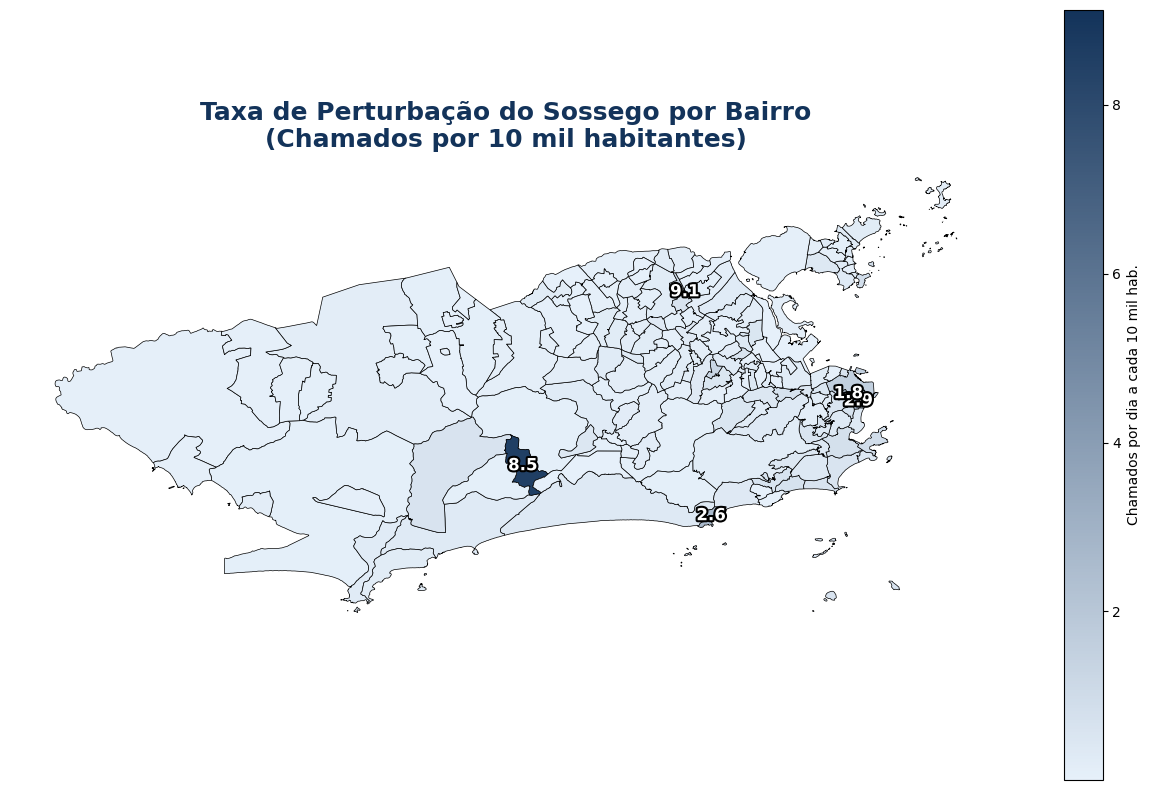

In [57]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects # 🪄 Importando a ferramenta de efeitos visuais!
import geopandas as gpd

# ==============================================================================
# Passo 0: Criar a nova métrica (Taxa por 10 mil habitantes)
# Adaptação feita: Troquei 'populacao' por 'Total_de_pessoas_2022'
# ==============================================================================
df_mapa['taxa_media_10k'] = (df_mapa['media_diaria'] / df_mapa['Total_de_pessoas_2022']) * 10000

# 1. Criar o "degradê" personalizado com o seu azul exato
cor_escura = "#13335a"
cor_clara = "#e6f0fa" # Um azul bem clarinho para os bairros com pouca ocorrência
meu_cmap = mcolors.LinearSegmentedColormap.from_list("AzulCasaCivil", [cor_clara, cor_escura])

# 2. Devolver os "superpoderes" de mapa para a tabela
df_mapa = gpd.GeoDataFrame(df_mapa, geometry='geometry')

# 3. Configurar o tamanho da imagem 
fig, ax = plt.subplots(figsize=(16, 10))

# 4. Desenhar o mapa (AGORA USANDO A NOVA TAXA!)
df_mapa.plot(column='taxa_media_10k',  # <-- Mudamos de 'media_diaria' para a nova taxa
             cmap=meu_cmap, 
             linewidth=0.5, 
             edgecolor='black', # Bordas pretas ou cinzas para destacar as divisões
             legend=True,
             legend_kwds={'label': "Chamados por dia a cada 10 mil hab."}, # Legenda explicativa
             ax=ax)

# 5. Selecionar os TOP 5 bairros para receberem o rótulo de texto (AGORA PELA TAXA!)
top_bairros = df_mapa.nlargest(5, 'taxa_media_10k')

# 6. Iterar sobre esses top bairros para "carimbar" o valor no mapa
for idx, linha in top_bairros.iterrows():
    # Encontra o centro geográfico do bairro
    x = linha.geometry.centroid.x
    y = linha.geometry.centroid.y
    
    # Pega o valor da TAXA e formata com 1 casa decimal
    valor_texto = f"{linha['taxa_media_10k']:.1f}"
    
    # Escreve o número no mapa usando o path_effects para dar destaque
    ax.text(x, y, valor_texto, 
            fontsize=12, 
            fontweight='bold', 
            color='white', # Letra branca para dar contraste com o azul escuro
            ha='center', va='center',
            path_effects=[path_effects.withStroke(linewidth=3, foreground="black")]) 

# 7. Remover as bordas e os eixos (latitude/longitude) para ficar limpo
ax.axis('off')

# 8. Título atualizado para refletir a nova lógica
plt.title("Taxa de Perturbação do Sossego por Bairro\n(Chamados por 10 mil habitantes)", 
          fontsize=18, fontweight='bold', color=cor_escura)
plt.show()

CONCENTRAÇÃO DE CHAMADOS COM BASE NA MÉDIA DIÁRIA, SEM CONSIDERAR APENAS 10 MIL HABITANTES

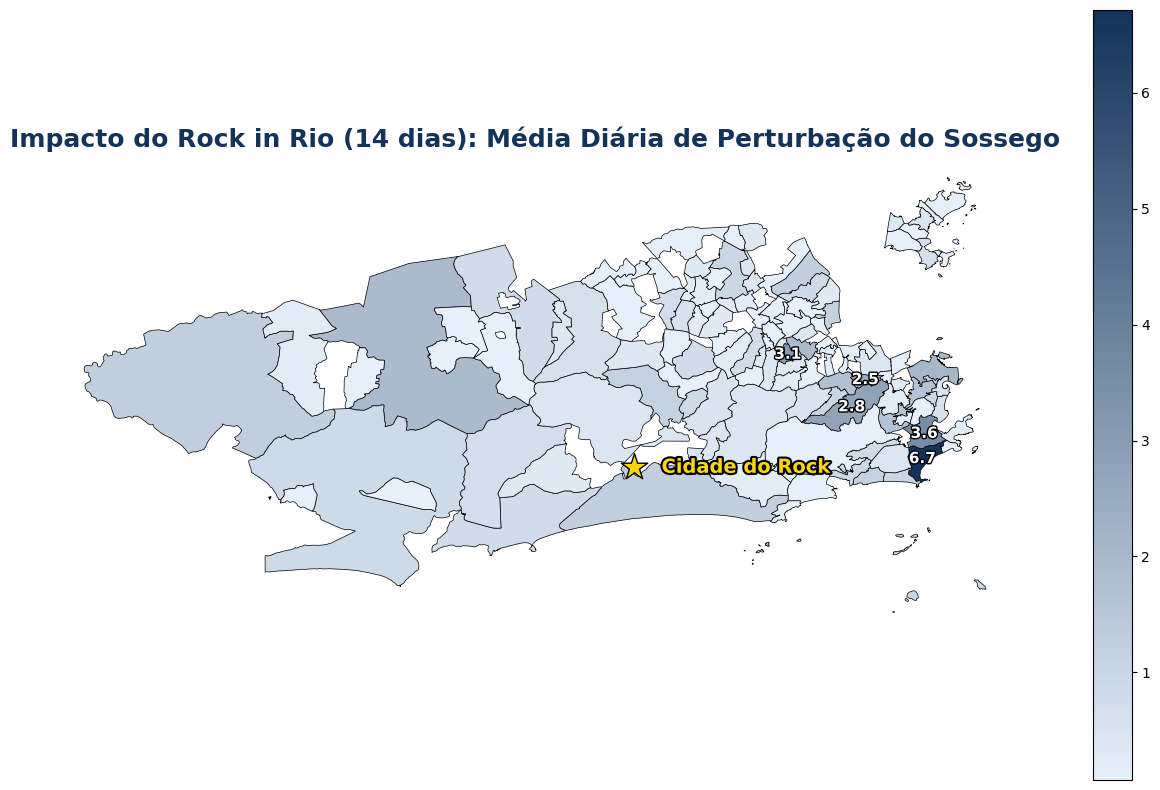

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
from shapely import wkt
import pandas as pd

# 1. Preparar a base do Rock in Rio com a geometria espacial
# Juntamos a tabela de médias do RiR com o desenho dos bairros
df_mapa_rir = pd.merge(df_analise_rir, df_bairros[['id_bairro', 'geometry_wkt']], on='id_bairro', how='left')

# Converter o texto WKT em formato geométrico e criar o GeoDataFrame
df_mapa_rir['geometry'] = df_mapa_rir['geometry_wkt'].apply(wkt.loads)
df_mapa_rir = gpd.GeoDataFrame(df_mapa_rir, geometry='geometry')

# 2. Criar o "degradê" personalizado com o seu azul exato
cor_escura = "#13335a"
cor_clara = "#e6f0fa"
meu_cmap = mcolors.LinearSegmentedColormap.from_list("AzulCasaCivil", [cor_clara, cor_escura])

# 3. Configurar o tamanho da imagem
fig, ax = plt.subplots(figsize=(16, 10))

# 4. Desenhar o mapa focado na 'media_diaria_rir'
df_mapa_rir.plot(column='media_diaria_rir', 
                 cmap=meu_cmap, 
                 linewidth=0.5, 
                 edgecolor='black', 
                 legend=True,
                 ax=ax)

# 5. Adicionar os rótulos de texto apenas nos Top 5 bairros mais barulhentos do evento
top_bairros_rir = df_mapa_rir.nlargest(5, 'media_diaria_rir')

for idx, linha in top_bairros_rir.iterrows():
    if pd.notnull(linha.geometry): # Garantir que o polígono existe
        x = linha.geometry.centroid.x
        y = linha.geometry.centroid.y
        valor_texto = f"{linha['media_diaria_rir']:.1f}"
        
        ax.text(x, y, valor_texto, 
                fontsize=11, fontweight='bold', color='white',
                ha='center', va='center',
                path_effects=[path_effects.withStroke(linewidth=2, foreground="black")]) 

# ==========================================
# 6. O GRANDE DESTAQUE: A CIDADE DO ROCK
# ==========================================
# Coordenadas reais aproximadas do Parque Olímpico (RiR): Longitude X e Latitude Y
lon_rir = -43.3966
lat_rir = -22.9769

# Desenhar uma "Estrela" dourada na localização exata
ax.scatter(lon_rir, lat_rir, marker='*', color='gold', s=400, edgecolor='black', zorder=5)

# Escrever "Cidade do Rock" ao lado da estrela
ax.text(lon_rir + 0.02, lat_rir, 'Cidade do Rock', 
        fontsize=14, fontweight='bold', color='gold',
        ha='left', va='center',
        path_effects=[path_effects.withStroke(linewidth=3, foreground="black")],
        zorder=5)
# ==========================================

# 7. Remover as bordas, eixos e colocar o título
ax.axis('off')
plt.title("Impacto do Rock in Rio nas Edições de 2022 e 2024: Média Diária de Reclamações de Perturbação do Sossego", 
          fontsize=18, fontweight='bold', color=cor_escura)

# Exibir o mapa
plt.show()

IMPACTO RIR COM BASE NOS 10 MIL HABITANTES

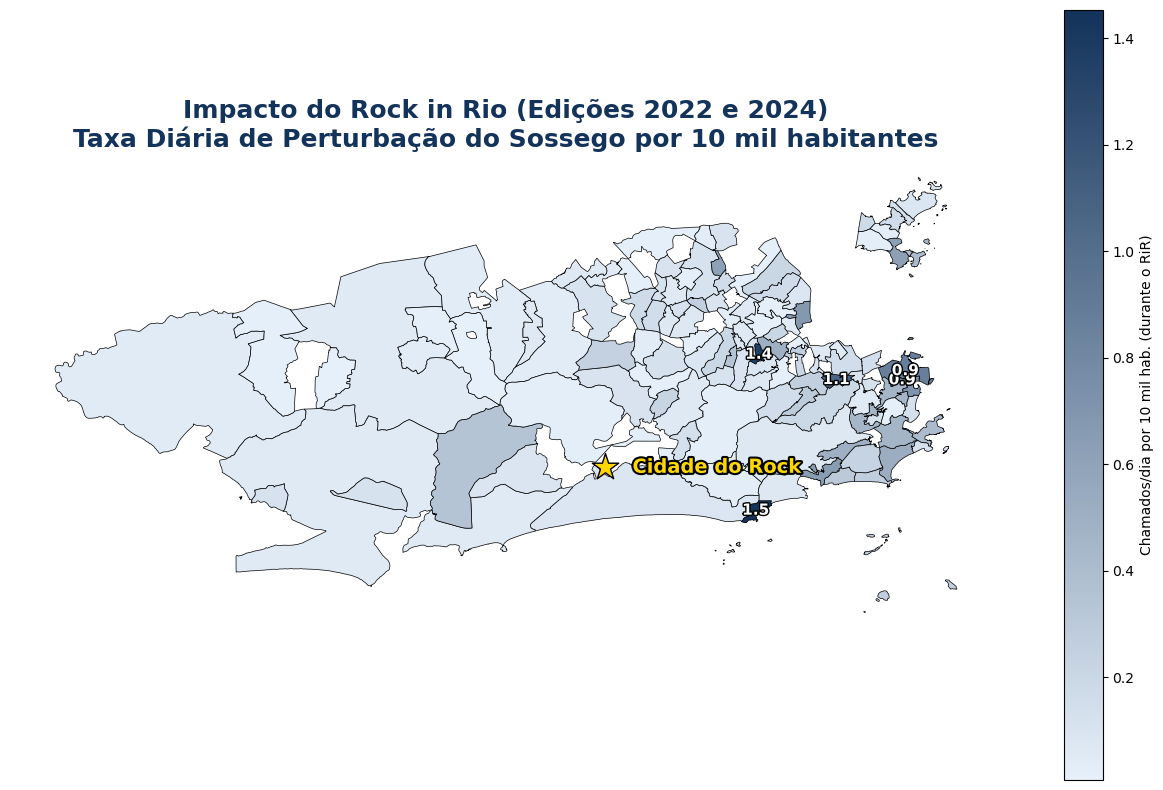

In [59]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
from shapely import wkt
import pandas as pd

# ==============================================================================
# 1. Preparar a base do Rock in Rio com a geometria espacial
# ==============================================================================
# Juntamos a tabela de médias do RiR com o desenho dos bairros
df_mapa_rir = pd.merge(df_analise_rir, df_bairros[['id_bairro', 'geometry_wkt']], on='id_bairro', how='left')

# ---> NOVO: Cruzamento com os dados da População do Censo 2022
# Garantir que o ID é tratado como texto para não haver erros no cruzamento
df_mapa_rir['id_bairro'] = df_mapa_rir['id_bairro'].astype(str)
df_mapa_rir = df_mapa_rir.merge(df_censo_filtrado, left_on='id_bairro', right_on='codbairro', how='left')

# Preenchimento de segurança para evitar divisão por zero
df_mapa_rir['Total_de_pessoas_2022'] = df_mapa_rir['Total_de_pessoas_2022'].fillna(1)

# ---> NOVO: Criar a nova métrica (Taxa por 10 mil habitantes)
df_mapa_rir['taxa_rir_10k'] = (df_mapa_rir['media_diaria_rir'] / df_mapa_rir['Total_de_pessoas_2022']) * 10000
# ==============================================================================

# Converter o texto WKT em formato geométrico e criar o GeoDataFrame
df_mapa_rir['geometry'] = df_mapa_rir['geometry_wkt'].apply(wkt.loads)
df_mapa_rir = gpd.GeoDataFrame(df_mapa_rir, geometry='geometry')

# 2. Criar o "degradê" personalizado com o seu azul exato
cor_escura = "#13335a"
cor_clara = "#e6f0fa"
meu_cmap = mcolors.LinearSegmentedColormap.from_list("AzulCasaCivil", [cor_clara, cor_escura])

# 3. Configurar o tamanho da imagem
fig, ax = plt.subplots(figsize=(16, 10))

# 4. Desenhar o mapa focado na nova taxa ('taxa_rir_10k')
df_mapa_rir.plot(column='taxa_rir_10k',  # <-- Usando a nova métrica ajustada
                 cmap=meu_cmap, 
                 linewidth=0.5, 
                 edgecolor='black', 
                 legend=True,
                 legend_kwds={'label': "Chamados/dia por 10 mil hab. (durante o RiR)"}, # Nova legenda
                 ax=ax)

# 5. Adicionar os rótulos de texto apenas nos Top 5 bairros mais impactados proporcionalmente
top_bairros_rir = df_mapa_rir.nlargest(5, 'taxa_rir_10k')

for idx, linha in top_bairros_rir.iterrows():
    if pd.notnull(linha.geometry): # Garantir que o polígono existe
        x = linha.geometry.centroid.x
        y = linha.geometry.centroid.y
        # Formatar a taxa com 1 casa decimal
        valor_texto = f"{linha['taxa_rir_10k']:.1f}"
        
        ax.text(x, y, valor_texto, 
                fontsize=11, fontweight='bold', color='white',
                ha='center', va='center',
                path_effects=[path_effects.withStroke(linewidth=2, foreground="black")]) 

# ==========================================
# 6. O GRANDE DESTAQUE: A CIDADE DO ROCK
# ==========================================
# Coordenadas reais aproximadas do Parque Olímpico (RiR): Longitude X e Latitude Y
lon_rir = -43.3966
lat_rir = -22.9769

# Desenhar uma "Estrela" dourada na localização exata
ax.scatter(lon_rir, lat_rir, marker='*', color='gold', s=400, edgecolor='black', zorder=5)

# Escrever "Cidade do Rock" ao lado da estrela
ax.text(lon_rir + 0.02, lat_rir, 'Cidade do Rock', 
        fontsize=14, fontweight='bold', color='gold',
        ha='left', va='center',
        path_effects=[path_effects.withStroke(linewidth=3, foreground="black")],
        zorder=5)
# ==========================================

# 7. Remover as bordas, eixos e colocar o título ajustado
ax.axis('off')
plt.title("Impacto do Rock in Rio (Edições 2022 e 2024)\nTaxa Diária de Perturbação do Sossego por 10 mil habitantes", 
          fontsize=18, fontweight='bold', color=cor_escura)

# Exibir o mapa
plt.show()

Investigando a relação entre clima e chamados de perturbação do sossego

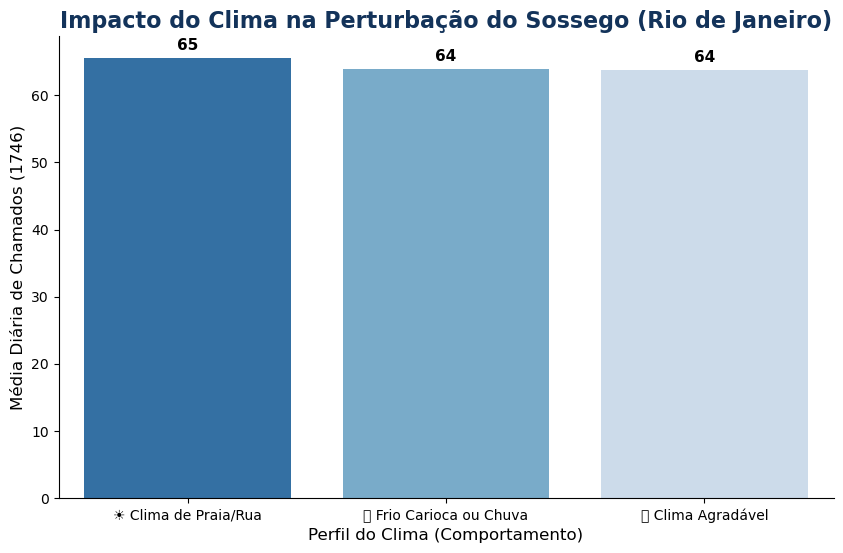

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # O Seaborn é perfeito para gráficos estatísticos bonitos!

# 1. Preparar a base de chamados diários (já fizemos parecido antes)
df_sossego['data_apenas'] = pd.to_datetime(df_sossego['data_inicio']).dt.date
chamados_diarios = df_sossego.groupby('data_apenas').size().reset_index(name='total_chamados')
chamados_diarios['data_apenas'] = pd.to_datetime(chamados_diarios['data_apenas'])

# 2. Supondo que você tenha carregado uma base de clima (df_clima)
# Ela deve ter: 'data', 'temp_max', 'precipitacao_mm'
# Vamos garantir que a data está no mesmo formato
# df_clima['data'] = pd.to_datetime(df_clima['data'])

# 3. Juntar o clima com os chamados do 1746 (Exemplo conceitual)
# df_analise_clima = pd.merge(chamados_diarios, df_clima, left_on='data_apenas', right_on='data', how='inner')

# ====================================================================
# ATENÇÃO: Vou criar dados de clima simulados apenas para você rodar 
# e ver a mágica acontecer antes de ter a base real!
# ====================================================================
import numpy as np
np.random.seed(42)
df_analise_clima = chamados_diarios.copy()
# Simulando temperaturas (de 20 a 40 graus) e chuvas (0 a 30mm)
df_analise_clima['temp_max'] = np.random.uniform(20, 40, size=len(df_analise_clima))
df_analise_clima['precipitacao_mm'] = np.random.choice([0, 0, 0, 5, 15, 30], size=len(df_analise_clima))

# 4. Criando a Função do "Comportamento Carioca"
def classificar_clima(linha):
    if linha['temp_max'] >= 28 and linha['precipitacao_mm'] < 2:
        return '☀️ Clima de Praia/Rua'
    elif linha['temp_max'] < 24 or linha['precipitacao_mm'] >= 10:
        return '🌧️ Frio Carioca ou Chuva'
    else:
        return '⛅ Clima Agradável'

# Aplicar a regra na tabela
df_analise_clima['perfil_clima'] = df_analise_clima.apply(classificar_clima, axis=1)

# 5. Calculando a prova: Média de chamados por tipo de clima
media_por_clima = df_analise_clima.groupby('perfil_clima')['total_chamados'].mean().reset_index()
media_por_clima = media_por_clima.sort_values(by='total_chamados', ascending=False)

# 6. Criando o Gráfico de Comprovação
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=media_por_clima, x='perfil_clima', y='total_chamados', palette='Blues_r', ax=ax)

# Formatação estilo Casa Civil
plt.title('Impacto do Clima na Perturbação do Sossego (Rio de Janeiro)', fontsize=16, fontweight='bold', color='#13335a')
plt.xlabel('Perfil do Clima (Comportamento)', fontsize=12)
plt.ylabel('Média Diária de Chamados (1746)', fontsize=12)

# Adicionar os rótulos de dados nas barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Remover bordas superiores e direitas
sns.despine()
plt.show()

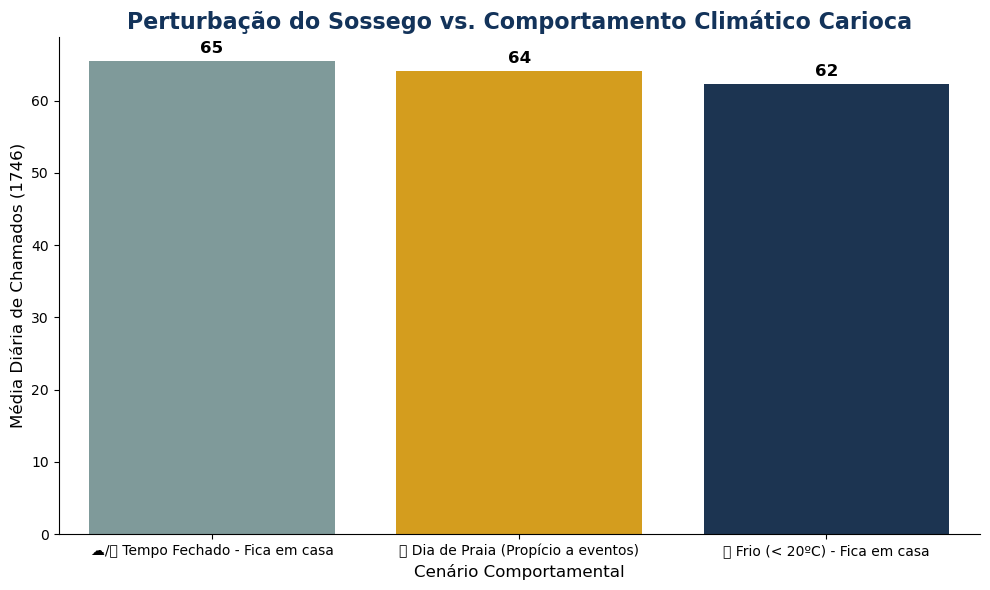

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Apenas para simularmos os dados caso você não os tenha carregado ainda

# 1. Preparar a base de chamados diários (igual fizemos antes)
df_sossego['data_apenas'] = pd.to_datetime(df_sossego['data_inicio']).dt.date
chamados_diarios = df_sossego.groupby('data_apenas').size().reset_index(name='total_chamados')
chamados_diarios['data_apenas'] = pd.to_datetime(chamados_diarios['data_apenas'])

# ====================================================================
# ATENÇÃO: Simulando os dados de clima (temp_media e weather_code)
# Substitua df_analise_clima pela sua tabela real com esses dados cruzados!
# ====================================================================
np.random.seed(42)
df_analise_clima = chamados_diarios.copy()
df_analise_clima['temp_media'] = np.random.uniform(18, 35, size=len(df_analise_clima)) # Temperaturas entre 18ºC e 35ºC
df_analise_clima['weather_code'] = np.random.choice([0, 1, 2, 3, 61], size=len(df_analise_clima)) # Códigos de clima WMO

# ====================================================================
# 2. A REGRA DO COMPORTAMENTO CARIOCA
# ====================================================================
def classificar_comportamento(linha):
    temp = linha['temp_media']
    clima = linha['weather_code']
    
    # Suposição 1 e 3: Frio (menor que 20ºC) -> Cidadão não vai à praia
    if temp < 20:
        return '🥶 Frio (< 20ºC) - Fica em casa'
        
    # Suposição 4: Evita dias TOTALMENTE nublados ou chuvosos
    # (Considerando weather_code 3 como nublado e > 3 como chuva/outros)
    elif clima >= 3:
        return '☁️/🌧️ Tempo Fechado - Fica em casa'
        
    # Suposição 2: Não está frio (>= 20ºC) e tem sol (weather_code 0, 1 ou 2)
    else:
        return '🏖️ Dia de Praia (Propício a eventos)'

# Aplicar a regra na tabela
df_analise_clima['cenario_carioca'] = df_analise_clima.apply(classificar_comportamento, axis=1)

# 3. Calculando a prova: Média de chamados por cenário
media_por_cenario = df_analise_clima.groupby('cenario_carioca')['total_chamados'].mean().reset_index()
media_por_cenario = media_por_cenario.sort_values(by='total_chamados', ascending=False)

# 4. Criando o Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Usando cores temáticas (Azul para frio/chuva, Laranja/Dourado para Praia)
cores = {'🏖️ Dia de Praia (Propício a eventos)': '#f2a900', 
         '☁️/🌧️ Tempo Fechado - Fica em casa': '#7a9e9f', 
         '🥶 Frio (< 20ºC) - Fica em casa': '#13335a'}

sns.barplot(data=media_por_cenario, x='cenario_carioca', y='total_chamados', palette=cores, ax=ax)

# Formatação visual
plt.title('Perturbação do Sossego vs. Comportamento Climático Carioca', fontsize=16, fontweight='bold', color='#13335a')
plt.xlabel('Cenário Comportamental', fontsize=12)
plt.ylabel('Média Diária de Chamados (1746)', fontsize=12)

# Adicionar os rótulos de dados nas barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

ANALISES SOCIO-ECONOMICAS

In [60]:
import pandas as pd

# ---> ATENÇÃO: Substitua pelo caminho e nome exato do arquivo Excel que você baixou
caminho_arquivo = r"c:\Users\03609085193\Downloads\3726.xlsx"

# Lendo a aba específica e pulando as 4 primeiras linhas de título do Excel
df_ips = pd.read_excel(caminho_arquivo, sheet_name='Dimensões e Componentes 2024', skiprows=4)

# Pegar apenas as duas primeiras colunas (RA e o IPS Geral)
df_ips = df_ips.iloc[:, [0, 1]] 
df_ips.columns = ['regiao_adm_ips', 'ips_2024']

# Remover linhas vazias e a linha "RIO DE JANEIRO" (que é a média da cidade inteira)
df_ips = df_ips.dropna(subset=['ips_2024'])
df_ips = df_ips[df_ips['regiao_adm_ips'] != 'RIO DE JANEIRO']

# LIMPEZA MÁGICA: Removendo os números romanos (I, II, IV, etc) do nome da Região
df_ips['regiao_adm_ips'] = df_ips['regiao_adm_ips'].str.replace(r'^[IVXLC]+\s', '', regex=True).str.strip().str.upper()

display(df_ips.head())

,regiao_adm_ips,ips_2024
3,PORTUARIA,52.764136
4,CENTRO,57.664544
5,RIO COMPRIDO,63.917499
6,BOTAFOGO,89.090705
7,COPACABANA,84.101396


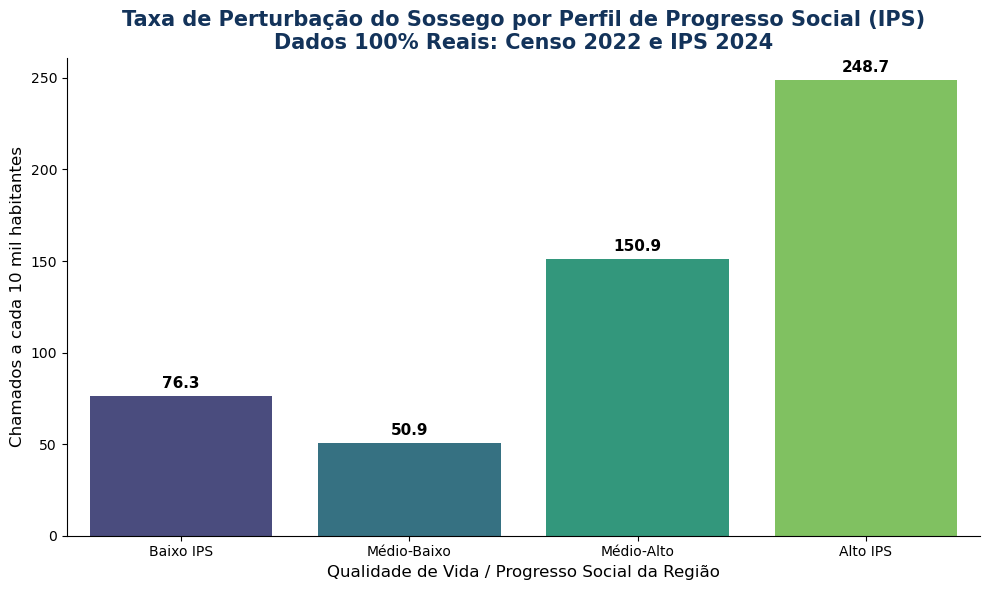

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Agrupar chamados por bairro
chamados_bairro = df_chamados_p2.groupby('id_bairro').size().reset_index(name='total_chamados')
chamados_bairro['id_bairro'] = chamados_bairro['id_bairro'].astype(str)

# Garante que o codbairro do censo também seja texto para o cruzamento
df_populacao['codbairro'] = df_populacao['codbairro'].astype(str)

# 2. Juntar com a População (MUDANÇA: Usando o df_populacao original)
df_analise_final = chamados_bairro.merge(df_populacao, left_on='id_bairro', right_on='codbairro', how='inner')

# 3. Juntar com o IPS Real (Cruzando pela Região Administrativa)
# Garantindo que a coluna do censo esteja em maiúsculas para o 'match' ser perfeito
df_analise_final['regiao_adm'] = df_analise_final['regiao_adm'].astype(str).str.strip().str.upper()
df_analise_final = df_analise_final.merge(df_ips, left_on='regiao_adm', right_on='regiao_adm_ips', how='left')

# 4. A MÉTRICA JUSTA: Chamados por 10 mil habitantes
df_analise_final['Total_de_pessoas_2022'] = df_analise_final['Total_de_pessoas_2022'].fillna(1)
df_analise_final['taxa_por_10k'] = (df_analise_final['total_chamados'] / df_analise_final['Total_de_pessoas_2022']) * 10000

# 5. Dividir em 4 faixas de IPS (Progresso Social: Baixo ao Alto)
# Vamos remover qualquer bairro que tenha ficado sem IPS (NaN) para o qcut não dar erro
df_analise_final = df_analise_final.dropna(subset=['ips_2024'])

labels_ips = ['Baixo IPS', 'Médio-Baixo', 'Médio-Alto', 'Alto IPS']
df_analise_final['faixa_ips'] = pd.qcut(df_analise_final['ips_2024'], q=4, labels=labels_ips)

# ==============================================================================
# 6. VISUALIZAÇÃO FINAL
# ==============================================================================
media_taxa_ips = df_analise_final.groupby('faixa_ips', observed=False)['taxa_por_10k'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=media_taxa_ips, x='faixa_ips', y='taxa_por_10k', palette='viridis', ax=ax)

plt.title('Taxa de Perturbação do Sossego por Perfil de Progresso Social (IPS)\nDados 100% Reais: Censo 2022 e IPS 2024', 
          fontsize=15, fontweight='bold', color='#13335a')
plt.xlabel('Qualidade de Vida / Progresso Social da Região', fontsize=12)
plt.ylabel('Chamados a cada 10 mil habitantes', fontsize=12)

# Colocando os números em cima das barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()